# ANALISIS SENTIMEN DAN DETEKSI ANOMALI ULASAN STEAM MOBILE

Notebook ini disusun mengikuti alur penelitian CRISP-DM:
1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation

Pipeline pemodelan final:
**pengumpulan data → deteksi bahasa → penggabungan dan cleaning/deduplikasi → pelabelan `polarity` → pemisahan dataset Bahasa Inggris dan Bahasa Indonesia → preprocessing → filtering → balancing masing-masing dataset → pembagian data 80:20 → TF-IDF fit pada data latih → Multinomial Naive Bayes → evaluasi → deteksi anomali**.

Catatan:
- Data dari seluruh negara digabungkan pada tahap Data Understanding dan persiapan awal data.
- Setelah pemisahan berdasarkan kolom `bahasa`, dataset Bahasa Inggris dan Bahasa Indonesia diproses secara terpisah dan tidak digabungkan kembali untuk pemodelan.
- Pemodelan, evaluasi, deteksi anomali, dan penyimpanan hasil dilakukan secara terpisah untuk Bahasa Inggris dan Bahasa Indonesia.
- Tidak menggunakan Streamlit.


In [1]:
!pip install google-play-scraper langdetect -q

import os
import re
import json
import time
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from concurrent.futures import ThreadPoolExecutor, as_completed

from google_play_scraper import reviews, Sort
from langdetect import detect, DetectorFactory

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")
DetectorFactory.seed = 0

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)

print("✅ Library berhasil dimuat.")



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
✅ Library berhasil dimuat.


## 1. Business Understanding

Permasalahan penelitian adalah klasifikasi sentimen ulasan pengguna Steam Mobile dan identifikasi ketidaksesuaian antara rating bintang dengan hasil klasifikasi sentimen pada teks ulasan.

## 2. Data Understanding

Data ulasan diperoleh dari Google Play Store menggunakan library `google-play-scraper` dengan daftar pengambilan sebanyak 189 negara atau wilayah. Informasi yang digunakan dari setiap ulasan meliputi `review_id`, `review`, `rating`, dan `date`, sedangkan kolom `negara` menunjukkan lokasi pengambilan data. Setelah ulasan diperoleh, bahasa pada setiap `review` dideteksi menggunakan library `langdetect` dan disimpan pada kolom `bahasa`. Data dari seluruh negara kemudian digabungkan dalam satu DataFrame untuk proses cleaning dan deduplikasi. Setelah pelabelan berdasarkan `rating`, ditambahkan kolom `polarity`, sehingga dataset bersih memiliki kolom `negara`, `review_id`, `review`, `rating`, `date`, `bahasa`, dan `polarity`.

## 3. Data Preparation

Tahap Data Preparation meliputi cleaning, deduplikasi berdasarkan `review_id`, pelabelan sentimen berdasarkan `rating`, pemisahan data Bahasa Inggris dan Bahasa Indonesia berdasarkan kolom `bahasa`, preprocessing teks secara terpisah, filtering hasil preprocessing yang kosong, balancing pada masing-masing dataset, serta pembagian data menjadi data latih dan data uji dengan rasio 80:20.

## 4. Modeling

Dataset Bahasa Inggris dan Bahasa Indonesia dimodelkan secara terpisah. Teks direpresentasikan menggunakan TF-IDF dengan vectorizer yang berbeda untuk masing-masing bahasa. TF-IDF di-fit hanya pada data latih, kemudian data latih dan data uji diklasifikasikan menggunakan algoritma Multinomial Naive Bayes.

## 5. Evaluation

Performa model Bahasa Inggris dan Bahasa Indonesia dievaluasi secara terpisah menggunakan accuracy, precision, recall, F1-score, dan confusion matrix. Hasil prediksi model juga digunakan untuk mendeteksi anomali dengan membandingkan `polarity` berdasarkan rating dan `sentiment_model` hasil klasifikasi.


In [2]:
# Simpan daftar negara ke CSV (jalankan sekali saja)
import pandas as pd

negara_dunia = [
    ('Amerika Serikat','en','us'), ('Kanada','en','ca'), ('Meksiko','es','mx'),
    ('Brasil','pt','br'), ('Argentina','es','ar'), ('Chile','es','cl'),
    ('Kolombia','es','co'), ('Peru','es','pe'), ('Venezuela','es','ve'),
    ('Ekuador','es','ec'), ('Bolivia','es','bo'), ('Paraguay','es','py'),
    ('Uruguay','es','uy'), ('Jamaika','en','jm'), ('Trinidad dan Tobago','en','tt'),
    ('Barbados','en','bb'), ('Bahama','en','bs'), ('Belize','en','bz'),
    ('Kosta Rika','es','cr'), ('Panama','es','pa'), ('Guatemala','es','gt'),
    ('Honduras','es','hn'), ('El Salvador','es','sv'), ('Nicaragua','es','ni'),
    ('Republik Dominika','es','do'), ('Haiti','fr','ht'), ('Kuba','es','cu'),
    ('Puerto Riko','es','pr'), ('Inggris','en','gb'), ('Irlandia','en','ie'),
    ('Prancis','fr','fr'), ('Jerman','de','de'), ('Italia','it','it'),
    ('Spanyol','es','es'), ('Portugal','pt','pt'), ('Belanda','nl','nl'),
    ('Belgia','fr','be'), ('Swiss','de','ch'), ('Austria','de','at'),
    ('Polandia','pl','pl'), ('Rusia','ru','ru'), ('Ukraina','uk','ua'),
    ('Turki','tr','tr'), ('Ceko','cs','cz'), ('Rumania','ro','ro'),
    ('Hungaria','hu','hu'), ('Yunani','el','gr'), ('Swedia','sv','se'),
    ('Norwegia','no','no'), ('Denmark','da','dk'), ('Finlandia','fi','fi'),
    ('Slovakia','sk','sk'), ('Slovenia','sl','si'), ('Bulgaria','bg','bg'),
    ('Serbia','sr','rs'), ('Kroasia','hr','hr'), ('Bosnia dan Herzegovina','bs','ba'),
    ('Makedonia Utara','mk','mk'), ('Albania','sq','al'), ('Montenegro','sr','me'),
    ('Latvia','lv','lv'), ('Lituania','lt','lt'), ('Estonia','et','ee'),
    ('Islandia','is','is'), ('Malta','mt','mt'), ('Luksemburg','fr','lu'),
    ('Belarus','be','by'), ('Moldova','ro','md'), ('Siprus','el','cy'),
    ('San Marino','it','sm'), ('Monako','fr','mc'), ('Liechtenstein','de','li'),
    ('Andorra','ca','ad'), ('Vatikan','it','va'), ('Jepang','ja','jp'),
    ('Korea Selatan','ko','kr'), ('China','zh','cn'), ('Taiwan','zh','tw'),
    ('Hong Kong','zh','hk'), ('Indonesia','id','id'), ('Malaysia','ms','my'),
    ('Thailand','th','th'), ('Vietnam','vi','vn'), ('Singapura','en','sg'),
    ('Filipina','tl','ph'), ('India','hi','in'), ('Pakistan','ur','pk'),
    ('Bangladesh','bn','bd'), ('Kamboja','km','kh'), ('Laos','lo','la'),
    ('Myanmar','my','mm'), ('Sri Lanka','si','lk'), ('Nepal','ne','np'),
    ('Kazakhstan','kk','kz'), ('Uzbekistan','uz','uz'), ('Kirgizstan','ky','kg'),
    ('Tajikistan','tg','tj'), ('Turkmenistan','tk','tm'), ('Azerbaijan','az','az'),
    ('Armenia','hy','am'), ('Georgia','ka','ge'), ('Mongolia','mn','mn'),
    ('Makau','zh','mo'), ('Brunei','ms','bn'), ('Timor-Leste','pt','tl'),
    ('Bhutan','dz','bt'), ('Maladewa','dv','mv'), ('Afghanistan','fa','af'),
    ('Arab Saudi','ar','sa'), ('Uni Emirat Arab','ar','ae'), ('Mesir','ar','eg'),
    ('Israel','he','il'), ('Iran','fa','ir'), ('Irak','ar','iq'),
    ('Yordania','ar','jo'), ('Lebanon','ar','lb'), ('Kuwait','ar','kw'),
    ('Qatar','ar','qa'), ('Oman','ar','om'), ('Bahrain','ar','bh'),
    ('Suriah','ar','sy'), ('Yaman','ar','ye'), ('Palestina','ar','ps'),
    ('Afrika Selatan','en','za'), ('Nigeria','en','ng'), ('Kenya','sw','ke'),
    ('Tanzania','sw','tz'), ('Ghana','en','gh'), ('Kamerun','fr','cm'),
    ('Senegal','fr','sn'), ('Pantai Gading','fr','ci'), ('Etiopia','am','et'),
    ('Uganda','sw','ug'), ('Mozambik','pt','mz'), ('Angola','pt','ao'),
    ('Zambia','en','zm'), ('Zimbabwe','en','zw'), ('Rwanda','fr','rw'),
    ('Botswana','en','bw'), ('Namibia','en','na'), ('Malawi','en','mw'),
    ('Mauritius','en','mu'), ('Tunisia','fr','tn'), ('Maroko','ar','ma'),
    ('Aljazair','ar','dz'), ('Libya','ar','ly'), ('Sudan','ar','sd'),
    ('Burkina Faso','fr','bf'), ('Mali','fr','ml'), ('Niger','fr','ne'),
    ('Togo','fr','tg'), ('Benin','fr','bj'), ('Gabon','fr','ga'),
    ('Republik Demokratik Kongo','fr','cd'), ('Republik Kongo','fr','cg'),
    ('Somalia','so','so'), ('Djibouti','fr','dj'), ('Eritrea','ti','er'),
    ('Madagaskar','fr','mg'), ('Komoro','ar','km'), ('Seychelles','fr','sc'),
    ('Tanjung Verde','pt','cv'), ('Guinea','fr','gn'), ('Guinea-Bissau','pt','gw'),
    ('Guinea Khatulistiwa','es','gq'), ('Sierra Leone','en','sl'), ('Liberia','en','lr'),
    ('Gambia','en','gm'), ('Sao Tome dan Principe','pt','st'), ('Afrika Tengah','fr','cf'),
    ('Chad','fr','td'), ('Sudan Selatan','en','ss'), ('Burundi','fr','bi'),
    ('Lesotho','en','ls'), ('Eswatini','en','sz'), ('Australia','en','au'),
    ('Selandia Baru','en','nz'), ('Papua Nugini','en','pg'), ('Fiji','en','fj'),
    ('Kepulauan Solomon','en','sb'), ('Vanuatu','fr','vu'), ('Samoa','en','ws'),
    ('Tonga','en','to'), ('Kiribati','en','ki'), ('Nauru','en','nr'),
    ('Tuvalu','en','tv'), ('Palau','en','pw'), ('Mikronesia','en','fm'),
    ('Kepulauan Marshall','en','mh'),
]

df_negara_dunia = pd.DataFrame(negara_dunia, columns=['negara', 'lang', 'country'])
df_negara_dunia.to_csv('daftar_negara.csv', index=False)
print(f"✅ Tersimpan: daftar_negara.csv ({len(df_negara_dunia)} negara)")

✅ Tersimpan: daftar_negara.csv (189 negara)


In [3]:
df_negara = pd.read_csv("daftar_negara.csv")

print(f"Jumlah negara dalam file: {len(df_negara)}")
print(df_negara.head())


Jumlah negara dalam file: 189
            negara lang country
0  Amerika Serikat   en      us
1           Kanada   en      ca
2          Meksiko   es      mx
3           Brasil   pt      br
4        Argentina   es      ar


## Data Understanding — Scraping Ulasan

Pengumpulan data menggunakan library `google-play-scraper` dengan parameter negara dan bahasa pengambilan berdasarkan daftar 189 negara atau wilayah. Data ulasan yang digunakan dinormalisasi menjadi kolom `review_id`, `review`, `rating`, dan `date`. Kolom `negara` berasal dari negara pengambilan data. Setelah teks `review` diperoleh, bahasa isi ulasan dideteksi menggunakan library `langdetect` dan disimpan pada kolom `bahasa`.

**Penting:** cell scraping membutuhkan waktu lama. Jalankan hanya ketika dataset perlu dikumpulkan ulang. Checkpoint digunakan agar negara yang sudah selesai tidak perlu diambil ulang.


In [4]:
# ══════════════════════════════════════════════════════════
# FINAL — Scraping berdasarkan parameter negara dan bahasa + checkpoint
# Deteksi bahasa isi review dilakukan setelah ulasan diperoleh
# ══════════════════════════════════════════════════════════
!pip install google-play-scraper langdetect -q

from google_play_scraper import reviews, Sort
from langdetect import detect, DetectorFactory
from concurrent.futures import ThreadPoolExecutor, as_completed
import pandas as pd
import time, warnings, json, os

warnings.filterwarnings('ignore')
DetectorFactory.seed = 0

APP_ID        = 'com.valvesoftware.android.steam.community'
MAX_RETRY     = 3
JEDA_RETRY    = 5      # jeda antar retry saat error (detik)
JEDA_BATCH    = 0.3    # jeda antar batch (detik)
BATCH_SIZE    = 200
MAX_WORKERS   = 10      # kalau banyak muncul ⚠️ Error di log, turunkan ke 7 atau 5
STAGNAN_LIMIT = 2       # anti fallback-loop, BUKAN pembatas jumlah data

CHECKPOINT_DIR = 'checkpoint_revisi1'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Baca daftar negara dari file CSV
df_negara_sumber = pd.read_csv('daftar_negara.csv')
NEGARA_REVISI = list(df_negara_sumber.itertuples(index=False, name=None))
print(f"🌍 Total negara: {len(NEGARA_REVISI)}")

def detect_lang(text):
    try:
        lang = detect(str(text))
        return 'zh' if lang.startswith('zh') else lang
    except:
        return 'unknown'

def checkpoint_path(country, lang):
    return os.path.join(CHECKPOINT_DIR, f'{country}_{lang}.json')

def simpan_checkpoint(country, lang, result):
    path = checkpoint_path(country, lang)
    tmp_path = path + '.tmp'
    with open(tmp_path, 'w', encoding='utf-8') as f:
        json.dump(result, f, ensure_ascii=False)
    os.replace(tmp_path, path)  # atomic write, aman kalau proses terhenti mendadak

def muat_checkpoint(country, lang):
    path = checkpoint_path(country, lang)
    if os.path.exists(path):
        try:
            with open(path, encoding='utf-8') as f:
                return json.load(f)
        except Exception:
            return None  # file rusak/kepotong -> anggap belum ada, tarik ulang
    return None

def proses_negara(item):
    nama, lang, country = item

    # Skip kalau negara ini sudah pernah selesai diproses sebelumnya
    cached = muat_checkpoint(country, lang)
    if cached is not None:
        return cached

    hasil, token = [], None
    seen_ids = set()
    stagnan = 0

    while True:
        data = []
        for attempt in range(MAX_RETRY):
            try:
                data, token = reviews(APP_ID, lang=lang, country=country,
                                      sort=Sort.NEWEST, count=BATCH_SIZE,
                                      continuation_token=token)
                break
            except Exception:
                data = []
                if attempt < MAX_RETRY - 1:
                    time.sleep(JEDA_RETRY * (attempt + 1))

        if not data:
            break

        # Guard anti-fallback-loop:
        # kalau semua review di batch ini SUDAH pernah kita ambil sebelumnya,
        # berarti Google Play kemungkinan besar fallback ke pool global yang sama
        # (bukan data spesifik negara ini) -> hentikan supaya tidak muter tanpa akhir.
        id_baru = [d['reviewId'] for d in data if d['reviewId'] not in seen_ids]
        if not id_baru:
            stagnan += 1
            if stagnan >= STAGNAN_LIMIT:
                break
        else:
            stagnan = 0

        for d in data:
            seen_ids.add(d['reviewId'])
        hasil.extend(data)

        # Tarik terus sampai continuation_token habis (tanpa batas jumlah),
        # guard di atas (seen_ids/stagnan) yang mencegah loop tak berujung
        # kalau API fallback ke pool data yang sama berulang.
        if token is None:
            break

        time.sleep(JEDA_BATCH)

    if not hasil:
        result = {'negara': nama, 'total': 0, 'raw': []}
        simpan_checkpoint(country, lang, result)
        return result

    df = pd.DataFrame(hasil)[['reviewId', 'content', 'score', 'at']].copy()
    df.columns = ['review_id', 'review', 'rating', 'date']
    df = df.dropna(subset=['review']).drop_duplicates(subset=['review_id'])
    df['bahasa'] = df['review'].apply(detect_lang)
    df['date'] = df['date'].astype(str)  # supaya aman di-JSON-kan

    result = {'negara': nama, 'total': len(df), 'raw': df.to_dict('records')}
    simpan_checkpoint(country, lang, result)
    return result

print(
    f'\n🚀 Scraping {len(NEGARA_REVISI)} negara berdasarkan '
    f'parameter bahasa dan country...\n'
)

data_revisi = [None] * len(NEGARA_REVISI)
idx_map_revisi = {item: i for i, item in enumerate(NEGARA_REVISI)}

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {executor.submit(proses_negara, item): item for item in NEGARA_REVISI}
    done = 0
    for future in as_completed(futures):
        item = futures[future]
        i = idx_map_revisi[item]
        try:
            result = future.result()
        except Exception as e:
            result = {'negara': item[0], 'total': 0, 'raw': []}
            print(f'⚠️ Error di {item[0]}: {e}')
        data_revisi[i] = result
        done += 1
        print(f'[{done}/{len(NEGARA_REVISI)}] {result["negara"]:<30} total={result["total"]:>6,}')

print('\n✅ Scraping selesai!')
print(f'📊 Total review terkumpul : {sum(r["total"] for r in data_revisi if r):,}')



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
🌍 Total negara: 189

🚀 Scraping 189 negara berdasarkan parameter bahasa dan country...

[1/189] Venezuela                      total=28,129
[2/189] Ekuador                        total=28,129
[3/189] Brasil                         total=22,367
[4/189] Argentina                      total=28,129
[5/189] Kanada                         total=81,955
[6/189] Kolombia                       total=28,129
[7/189] Chile                          total=28,129
[8/189] Peru                           total=28,129
[9/189] Amerika Serikat                total=81,955
[10/189] Bolivia                        total=28,129
[11/189] Meksiko                        total=28,129
[12/189] Uruguay                        total=28,129
[13/189] Kosta Rika                     total=28,129
[14/189] Belize                         total=81,955
[15/189] Bahama                         total=81,955
[16/189] Barb

## Data Understanding — Penggabungan, Cleaning, dan Deduplikasi

Hasil scraping dari seluruh negara digabungkan ke dalam satu DataFrame dengan kolom `negara`, `review_id`, `review`, `rating`, `date`, dan `bahasa`. Cleaning dilakukan dengan menghapus `review` kosong, menghapus duplikasi berdasarkan `review_id`, memastikan `rating` berupa numerik, serta mengubah `date` menjadi tipe datetime. DataFrame gabungan ini digunakan sebagai dasar analisis sebelum dataset dipisahkan berdasarkan bahasa untuk preprocessing dan pemodelan.


In [5]:
# Gabungkan hasil scraping
all_records = []

for r in data_revisi:
    if r is None:
        continue

    for rec in r["raw"]:
        all_records.append({
            "negara": r["negara"],
            "review_id": rec["review_id"],
            "review": rec["review"],
            "rating": rec["rating"],
            "date": rec["date"],
            "bahasa": rec.get("bahasa", "unknown")
        })

df = pd.DataFrame(all_records)

print(f"Total sebelum cleaning: {len(df):,}")
print(df.head())

# Cleaning dan deduplikasi
df = df.dropna(subset=["review"])
df = df[df["review"].astype(str).str.strip() != ""]
df = df.drop_duplicates(subset=["review_id"], keep="first")

df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df["date"] = pd.to_datetime(df["date"], errors="coerce")

df = df.dropna(subset=["rating", "date"])
df["rating"] = df["rating"].astype(int)
df["review"] = df["review"].astype(str).str.strip()

df = df.reset_index(drop=True)

print(f"Total setelah cleaning: {len(df):,}")
print(df.head())


Total sebelum cleaning: 4,858,138
            negara                             review_id  \
0  Amerika Serikat  ee288f0f-d9bc-4d1b-898e-2466d58e7547   
1  Amerika Serikat  b52736ee-27a9-412f-9ab5-d39222188f28   
2  Amerika Serikat  cc33596b-19a4-44f9-8fcc-1bab8d5f6a2b   
3  Amerika Serikat  f09a8de8-9cf1-4874-9599-3ac62a104a1e   
4  Amerika Serikat  70e47bf5-781a-44ce-82a0-c31c5dbd3b1b   

                                              review  rating  \
0  fr never expected steam's user care to be fast...       5   
1  Steam needs to make game creators declare AI u...       1   
2                                        thank gaben       5   
3  can't scan qr codes on GrapheneOS, that includ...       1   
4                                            So peak       5   

                  date bahasa  
0  2026-08-23 03:43:03     en  
1  2026-08-23 03:37:04     en  
2  2026-08-23 03:27:25     en  
3  2026-08-23 00:36:22     en  
4  2026-08-23 00:30:38     id  
Total setelah cleaning: 300,

## Data Preparation — Pelabelan Sentimen Berdasarkan Rating

Label sentimen disimpan pada kolom `polarity` berdasarkan nilai `rating`: rating 4–5 diberi label **positif**, rating 3 diberi label **netral**, dan rating 1–2 diberi label **negatif**. Setelah tahap ini, dataset bersih memiliki kolom `negara`, `review_id`, `review`, `rating`, `date`, `bahasa`, dan `polarity`.


In [6]:
def label_sentiment(score):
    if score >= 4:
        return "positif"
    elif score == 3:
        return "netral"
    else:
        return "negatif"

df["polarity"] = df["rating"].apply(label_sentiment)

print("Distribusi polarity:")
print(df["polarity"].value_counts())

print("\nContoh data:")
print(df[["review", "rating", "polarity"]].head())


Distribusi polarity:
polarity
negatif    138373
positif    138185
netral      24034
Name: count, dtype: int64

Contoh data:
                                              review  rating polarity
0  fr never expected steam's user care to be fast...       5  positif
1  Steam needs to make game creators declare AI u...       1  negatif
2                                        thank gaben       5  positif
3  can't scan qr codes on GrapheneOS, that includ...       1  negatif
4                                            So peak       5  positif


In [7]:
df.to_csv(
    "steam_reviews_clean.csv",
    index=False,
    encoding="utf-8"
)

df_check = pd.read_csv("steam_reviews_clean.csv")

print("File steam_reviews_clean.csv berhasil disimpan dan dibaca kembali.")
print(f"Jumlah data dalam file: {len(df_check):,}")
print(f"Jumlah kolom dalam file: {len(df_check.columns)}")
print(df_check.head())


File steam_reviews_clean.csv berhasil disimpan dan dibaca kembali.
Jumlah data dalam file: 300,592
Jumlah kolom dalam file: 7
            negara                             review_id  \
0  Amerika Serikat  ee288f0f-d9bc-4d1b-898e-2466d58e7547   
1  Amerika Serikat  b52736ee-27a9-412f-9ab5-d39222188f28   
2  Amerika Serikat  cc33596b-19a4-44f9-8fcc-1bab8d5f6a2b   
3  Amerika Serikat  f09a8de8-9cf1-4874-9599-3ac62a104a1e   
4  Amerika Serikat  70e47bf5-781a-44ce-82a0-c31c5dbd3b1b   

                                              review  rating  \
0  fr never expected steam's user care to be fast...       5   
1  Steam needs to make game creators declare AI u...       1   
2                                        thank gaben       5   
3  can't scan qr codes on GrapheneOS, that includ...       1   
4                                            So peak       5   

                  date bahasa polarity  
0  2026-08-23 03:43:03     en  positif  
1  2026-08-23 03:37:04     en  negatif  
2  20

## Data Understanding — 10 Negara dengan Ulasan Terbanyak

Jumlah ulasan dihitung dari DataFrame yang telah melalui cleaning dan deduplikasi, kemudian dipilih 10 negara dengan jumlah ulasan terbanyak.


In [8]:
df_per_negara = (
    df.groupby("negara")
      .size()
      .reset_index(name="total_review")
      .sort_values("total_review", ascending=False)
      .reset_index(drop=True)
)

top10_negara = df_per_negara.head(10).copy()

print(top10_negara)

top10_negara.to_csv(
    "top10_negara.csv",
    index=False,
    encoding="utf-8"
)

top10_check = pd.read_csv("top10_negara.csv")

print("\nIsi top10_negara.csv:")
print(top10_check)


            negara  total_review
0  Amerika Serikat         81955
1            Rusia         70838
2          Meksiko         28129
3           Brasil         22367
4            Turki         12308
5         Polandia         12164
6           Jerman         10770
7        Indonesia          7544
8            Haiti          6255
9    Korea Selatan          5870

Isi top10_negara.csv:
            negara  total_review
0  Amerika Serikat         81955
1            Rusia         70838
2          Meksiko         28129
3           Brasil         22367
4            Turki         12308
5         Polandia         12164
6           Jerman         10770
7        Indonesia          7544
8            Haiti          6255
9    Korea Selatan          5870


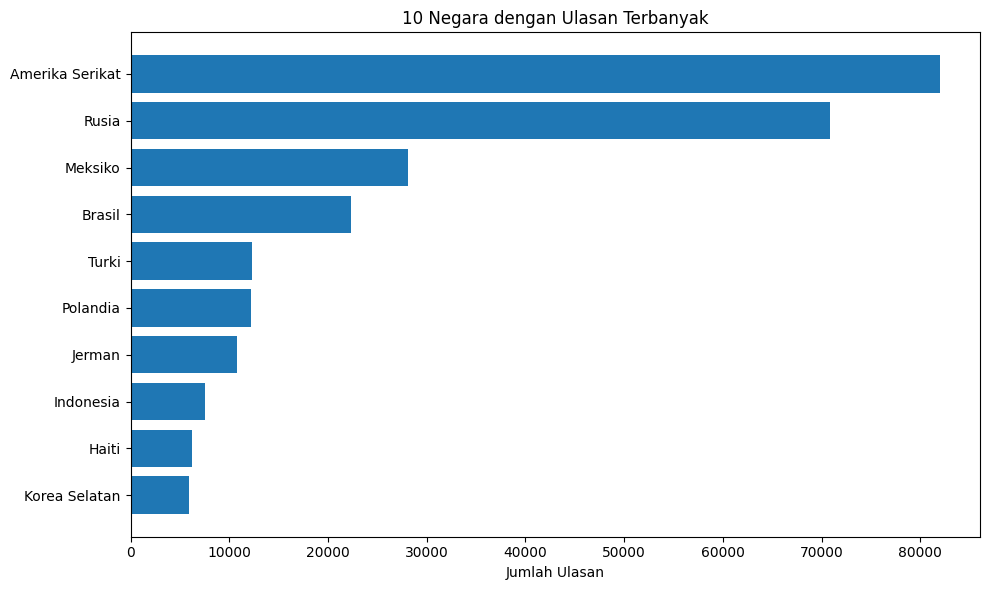

In [9]:
plt.figure(figsize=(10, 6))

plt.barh(
    top10_negara["negara"][::-1],
    top10_negara["total_review"][::-1]
)

plt.xlabel("Jumlah Ulasan")
plt.title("10 Negara dengan Ulasan Terbanyak")
plt.tight_layout()
plt.show()


## Data Understanding — Tiga Bahasa Terbanyak pada 10 Negara

Distribusi bahasa dihitung dari DataFrame hasil cleaning dan deduplikasi agar sumber data yang digunakan konsisten dengan perhitungan 10 negara dengan ulasan terbanyak. Untuk setiap negara pada daftar 10 besar, ditampilkan tiga bahasa dengan jumlah ulasan terbanyak.


In [10]:
NAMA_BAHASA = {
    "en": "English", "id": "Indonesian", "fr": "French",
    "es": "Spanish", "de": "German", "pt": "Portuguese",
    "ru": "Russian", "zh": "Chinese", "ja": "Japanese",
    "ko": "Korean", "ar": "Arabic", "tr": "Turkish",
    "it": "Italian", "nl": "Dutch", "pl": "Polish",
    "vi": "Vietnamese", "th": "Thai", "uk": "Ukrainian",
    "sv": "Swedish", "da": "Danish", "fi": "Finnish",
    "no": "Norwegian", "cs": "Czech", "ro": "Romanian",
    "hu": "Hungarian", "el": "Greek", "he": "Hebrew",
    "fa": "Persian", "hi": "Hindi", "bn": "Bengali",
    "ms": "Malay", "tl": "Filipino", "sk": "Slovak",
    "bg": "Bulgarian", "hr": "Croatian", "sr": "Serbian",
    "lt": "Lithuanian", "lv": "Latvian", "et": "Estonian",
    "sl": "Slovenian", "sq": "Albanian", "mk": "Macedonian",
    "bs": "Bosnian", "ca": "Catalan", "af": "Afrikaans",
    "sw": "Swahili", "am": "Amharic", "so": "Somali",
    "ur": "Urdu", "ne": "Nepali", "si": "Sinhala",
    "km": "Khmer", "lo": "Lao", "my": "Burmese",
    "ka": "Georgian", "hy": "Armenian", "az": "Azerbaijani",
    "kk": "Kazakh", "uz": "Uzbek", "mn": "Mongolian",
    "cy": "Welsh", "is": "Icelandic", "mt": "Maltese",
    "be": "Belarusian", "gl": "Galician", "eu": "Basque",
    "unknown": "Unknown"
}

top10_list = top10_negara["negara"].tolist()

df_top10_bahasa = df[
    df["negara"].isin(top10_list)
].copy()

df_all_bahasa = (
    df_top10_bahasa
    .groupby(["negara", "bahasa"])
    .size()
    .reset_index(name="jumlah")
)

df_all_bahasa["persentase"] = (
    df_all_bahasa["jumlah"]
    / df_all_bahasa.groupby("negara")["jumlah"].transform("sum")
    * 100
).round(1)

df_all_bahasa["bahasa"] = df_all_bahasa["bahasa"].map(
    lambda x: NAMA_BAHASA.get(x, x)
)

top3_bahasa = (
    df_all_bahasa
    .sort_values(["negara", "jumlah"], ascending=[True, False])
    .groupby("negara", as_index=False)
    .head(3)
    .reset_index(drop=True)
)

print(top3_bahasa)


             negara      bahasa  jumlah  persentase
0   Amerika Serikat     English   68191        83.2
1   Amerika Serikat      Somali    1817         2.2
2   Amerika Serikat   Afrikaans    1336         1.6
3            Brasil  Portuguese   17128        76.6
4            Brasil     English    1182         5.3
5            Brasil     Italian     640         2.9
6             Haiti      French    4696        75.1
7             Haiti     English     649        10.4
8             Haiti    Romanian      96         1.5
9         Indonesia  Indonesian    3873        51.3
10        Indonesia     English    1318        17.5
11        Indonesia    Filipino     547         7.3
12           Jerman      German    8729        81.0
13           Jerman     English    1094        10.2
14           Jerman    Romanian      88         0.8
15    Korea Selatan      Korean    5420        92.3
16    Korea Selatan     English     243         4.1
17    Korea Selatan      Somali      58         1.0
18          

In [11]:
top3_bahasa.to_csv(
    "top3_bahasa_per_negara.csv",
    index=False,
    encoding="utf-8"
)

top3_check = pd.read_csv(
    "top3_bahasa_per_negara.csv"
)

print(top3_check)


             negara      bahasa  jumlah  persentase
0   Amerika Serikat     English   68191        83.2
1   Amerika Serikat      Somali    1817         2.2
2   Amerika Serikat   Afrikaans    1336         1.6
3            Brasil  Portuguese   17128        76.6
4            Brasil     English    1182         5.3
5            Brasil     Italian     640         2.9
6             Haiti      French    4696        75.1
7             Haiti     English     649        10.4
8             Haiti    Romanian      96         1.5
9         Indonesia  Indonesian    3873        51.3
10        Indonesia     English    1318        17.5
11        Indonesia    Filipino     547         7.3
12           Jerman      German    8729        81.0
13           Jerman     English    1094        10.2
14           Jerman    Romanian      88         0.8
15    Korea Selatan      Korean    5420        92.3
16    Korea Selatan     English     243         4.1
17    Korea Selatan      Somali      58         1.0
18          

## Data Preparation — Preprocessing Bahasa Inggris dan Bahasa Indonesia

Dataset dipisahkan berdasarkan kolom `bahasa` sebelum preprocessing. Ulasan berbahasa Inggris diproses menjadi `df_en` menggunakan fungsi `preprocess_english`, sedangkan ulasan berbahasa Indonesia diproses menjadi `df_id` menggunakan fungsi `preprocess_indonesian`. Hasil preprocessing disimpan pada kolom `text_final`. Kedua dataset tetap terpisah dan tidak digabungkan kembali untuk tahap pemodelan.


In [12]:
stop_en = set(stopwords.words("english"))
stop_id = set(stopwords.words("indonesian"))

def preprocess_english(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = word_tokenize(text)

    tokens = [
        token for token in tokens
        if token not in stop_en
    ]

    return " ".join(tokens)


def preprocess_indonesian(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = word_tokenize(text)

    tokens = [
        token for token in tokens
        if token not in stop_id
    ]

    return " ".join(tokens)


In [13]:
# ==========================================
# PEMISAHAN DAN PREPROCESSING BAHASA INGGRIS
# ==========================================

df_en = df[
    df["bahasa"] == "en"
].copy()

df_en["text_final"] = (
    df_en["review"]
    .apply(preprocess_english)
)

print(
    "Jumlah data Bahasa Inggris:",
    len(df_en)
)

print(
    "\nData Bahasa Inggris:"
)

print(
    df_en[
        [
            "review",
            "bahasa",
            "text_final"
        ]
    ].head()
)

Jumlah data Bahasa Inggris: 84115

Data Bahasa Inggris:
                                              review bahasa  \
0  fr never expected steam's user care to be fast...     en   
1  Steam needs to make game creators declare AI u...     en   
2                                        thank gaben     en   
3  can't scan qr codes on GrapheneOS, that includ...     en   
5  app worked fine until a couple months ago now ...     en   

                                          text_final  
0   fr never expected steams user care fast fabulous  
1  steam needs make game creators declare ai use ...  
2                                        thank gaben  
3  cant scan qr codes grapheneos includes steam f...  
5  app worked fine couple months ago account app ...  


In [14]:
# ==========================================
# PEMISAHAN DAN PREPROCESSING BAHASA INDONESIA
# ==========================================

df_id = df[
    df["bahasa"] == "id"
].copy()

df_id["text_final"] = (
    df_id["review"]
    .apply(preprocess_indonesian)
)

print(
    "Jumlah data Bahasa Indonesia:",
    len(df_id)
)

print(
    "\nData Bahasa Indonesia:"
)

print(
    df_id[
        [
            "review",
            "bahasa",
            "text_final"
        ]
    ].head()
)

Jumlah data Bahasa Indonesia: 6096

Data Bahasa Indonesia:
                                                review bahasa  \
4                                              So peak     id   
15   iske andar Ham PC wale games Nahin khel sakte ...     id   
86                                         bahut bekar     id   
190          login sangat tidak praktis Dan merepotkan     id   
475                                       bad just bad     id   

                                            text_final  
4                                              so peak  
15   iske andar ham pc wale games nahin khel sakte ...  
86                                         bahut bekar  
190                           login praktis merepotkan  
475                                       bad just bad  


## Data Preparation — Filtering Dataset Pemodelan

Filtering dilakukan secara terpisah dengan menghapus baris yang memiliki `text_final` kosong. Hasilnya adalah `df_model_en` untuk Bahasa Inggris dan `df_model_id` untuk Bahasa Indonesia. Kedua DataFrame tersebut menjadi sumber balancing dan pemodelan masing-masing bahasa.


In [15]:
# ==========================================
# DATASET MODEL BAHASA INGGRIS
# ==========================================

df_model_en = df_en[
    df_en["text_final"].fillna("").str.strip() != ""
].copy()

df_model_en = df_model_en.reset_index(drop=True)

print(f"Jumlah data untuk model Bahasa Inggris: {len(df_model_en):,}")

print("\nDistribusi polarity:")

print(df_model_en["polarity"].value_counts())

print("\nIsi DataFrame:")

print(
    df_model_en[
        ["review", "rating", "bahasa", "polarity", "text_final"]
    ].head()
)

Jumlah data untuk model Bahasa Inggris: 84,028

Distribusi polarity:
polarity
negatif    42906
positif    32553
netral      8569
Name: count, dtype: int64

Isi DataFrame:
                                              review  rating bahasa polarity  \
0  fr never expected steam's user care to be fast...       5     en  positif   
1  Steam needs to make game creators declare AI u...       1     en  negatif   
2                                        thank gaben       5     en  positif   
3  can't scan qr codes on GrapheneOS, that includ...       1     en  negatif   
4  app worked fine until a couple months ago now ...       2     en  negatif   

                                          text_final  
0   fr never expected steams user care fast fabulous  
1  steam needs make game creators declare ai use ...  
2                                        thank gaben  
3  cant scan qr codes grapheneos includes steam f...  
4  app worked fine couple months ago account app ...  


In [16]:
# ==========================================
# DATASET MODEL BAHASA INDONESIA
# ==========================================

df_model_id = df_id[
    df_id["text_final"].fillna("").str.strip() != ""
].copy()

df_model_id = df_model_id.reset_index(drop=True)

print(f"Jumlah data untuk model Bahasa Indonesia: {len(df_model_id):,}")

print("\nDistribusi polarity:")

print(df_model_id["polarity"].value_counts())

print("\nIsi DataFrame:")

print(
    df_model_id[
        ["review", "rating", "bahasa", "polarity", "text_final"]
    ].head()
)

Jumlah data untuk model Bahasa Indonesia: 6,068

Distribusi polarity:
polarity
positif    3108
negatif    2656
netral      304
Name: count, dtype: int64

Isi DataFrame:
                                              review  rating bahasa polarity  \
0                                            So peak       5     id  positif   
1  iske andar Ham PC wale games Nahin khel sakte ...       1     id  negatif   
2                                        bahut bekar       5     id  positif   
3          login sangat tidak praktis Dan merepotkan       1     id  negatif   
4                                       bad just bad       1     id  negatif   

                                          text_final  
0                                            so peak  
1  iske andar ham pc wale games nahin khel sakte ...  
2                                        bahut bekar  
3                           login praktis merepotkan  
4                                       bad just bad  


## Data Preparation — Balancing Dataset

Balancing dilakukan secara terpisah pada `df_model_en` dan `df_model_id` sebelum pembagian data 80:20. Proses resampling menghasilkan `df_bal_en` untuk Bahasa Inggris dan `df_bal_id` untuk Bahasa Indonesia. Dataset hasil balancing tetap dipisahkan berdasarkan bahasa.


In [17]:
# ==========================================
# BALANCING DATA BAHASA INGGRIS
# ==========================================

print("Distribusi Bahasa Inggris sebelum balancing:")
print(df_model_en["polarity"].value_counts())

df_neg_en = df_model_en[
    df_model_en["polarity"] == "negatif"
]

df_pos_en = df_model_en[
    df_model_en["polarity"] == "positif"
]

df_neu_en = df_model_en[
    df_model_en["polarity"] == "netral"
]

target_en = min(
    len(df_neg_en),
    len(df_pos_en)
) // 2

target_en = max(
    target_en,
    len(df_neu_en) * 2
)

target_neg_en = min(
    target_en,
    len(df_neg_en)
)

target_pos_en = min(
    target_en,
    len(df_pos_en)
)

df_neg_bal_en = resample(
    df_neg_en,
    replace=False,
    n_samples=target_neg_en,
    random_state=42
)

df_pos_bal_en = resample(
    df_pos_en,
    replace=False,
    n_samples=target_pos_en,
    random_state=42
)

df_neu_bal_en = resample(
    df_neu_en,
    replace=True,
    n_samples=target_en,
    random_state=42
)

df_bal_en = pd.concat([
    df_neg_bal_en,
    df_pos_bal_en,
    df_neu_bal_en
]).reset_index(drop=True)

df_bal_en = (
    df_bal_en
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

print("\nDistribusi Bahasa Inggris setelah balancing:")
print(df_bal_en["polarity"].value_counts())

print(
    f"\nTotal data Bahasa Inggris setelah balancing: "
    f"{len(df_bal_en):,}"
)

Distribusi Bahasa Inggris sebelum balancing:
polarity
negatif    42906
positif    32553
netral      8569
Name: count, dtype: int64

Distribusi Bahasa Inggris setelah balancing:
polarity
negatif    17138
netral     17138
positif    17138
Name: count, dtype: int64

Total data Bahasa Inggris setelah balancing: 51,414


In [18]:
# ==========================================
# BALANCING DATA BAHASA INDONESIA
# ==========================================

print("Distribusi Bahasa Indonesia sebelum balancing:")
print(df_model_id["polarity"].value_counts())

df_neg_id = df_model_id[
    df_model_id["polarity"] == "negatif"
]

df_pos_id = df_model_id[
    df_model_id["polarity"] == "positif"
]

df_neu_id = df_model_id[
    df_model_id["polarity"] == "netral"
]

target_id = min(
    len(df_neg_id),
    len(df_pos_id)
) // 2

target_id = max(
    target_id,
    len(df_neu_id) * 2
)

target_neg_id = min(
    target_id,
    len(df_neg_id)
)

target_pos_id = min(
    target_id,
    len(df_pos_id)
)

df_neg_bal_id = resample(
    df_neg_id,
    replace=False,
    n_samples=target_neg_id,
    random_state=42
)

df_pos_bal_id = resample(
    df_pos_id,
    replace=False,
    n_samples=target_pos_id,
    random_state=42
)

df_neu_bal_id = resample(
    df_neu_id,
    replace=True,
    n_samples=target_id,
    random_state=42
)

df_bal_id = pd.concat([
    df_neg_bal_id,
    df_pos_bal_id,
    df_neu_bal_id
]).reset_index(drop=True)

df_bal_id = (
    df_bal_id
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

print("\nDistribusi Bahasa Indonesia setelah balancing:")
print(df_bal_id["polarity"].value_counts())

print(
    f"\nTotal data Bahasa Indonesia setelah balancing: "
    f"{len(df_bal_id):,}"
)

Distribusi Bahasa Indonesia sebelum balancing:
polarity
positif    3108
negatif    2656
netral      304
Name: count, dtype: int64

Distribusi Bahasa Indonesia setelah balancing:
polarity
negatif    1328
positif    1328
netral     1328
Name: count, dtype: int64

Total data Bahasa Indonesia setelah balancing: 3,984


## Data Preparation — Pembagian Data 80:20

Setelah balancing selesai, `df_bal_en` dan `df_bal_id` masing-masing dibagi menjadi data latih 80% dan data uji 20% menggunakan `train_test_split` dengan `stratify` berdasarkan `polarity`. Data Bahasa Inggris dan Bahasa Indonesia tetap dipisahkan. Pada tahap berikutnya, TF-IDF hanya di-fit pada data latih, sedangkan data uji hanya ditransformasikan untuk evaluasi.


In [19]:
# ==========================================
# PEMBAGIAN DATA 80:20 BAHASA INGGRIS
# ==========================================

X_en_raw = df_bal_en["text_final"]
y_en_raw = df_bal_en["polarity"]

X_train_en_raw, X_test_en_raw, y_train_en_raw, y_test_en = train_test_split(
    X_en_raw,
    y_en_raw,
    test_size=0.2,
    random_state=42,
    stratify=y_en_raw
)

print("Jumlah data latih Bahasa Inggris:", len(X_train_en_raw))
print("Jumlah data uji Bahasa Inggris:", len(X_test_en_raw))

print("Jumlah label latih Bahasa Inggris:", len(y_train_en_raw))
print("Jumlah label uji Bahasa Inggris:", len(y_test_en))

print("\nDistribusi label data latih Bahasa Inggris:")
print(y_train_en_raw.value_counts())

print("\nDistribusi label data uji Bahasa Inggris:")
print(y_test_en.value_counts())

print("\nContoh data latih Bahasa Inggris:")
print(X_train_en_raw.head())

Jumlah data latih Bahasa Inggris: 41131
Jumlah data uji Bahasa Inggris: 10283
Jumlah label latih Bahasa Inggris: 41131
Jumlah label uji Bahasa Inggris: 10283

Distribusi label data latih Bahasa Inggris:
polarity
negatif    13711
positif    13710
netral     13710
Name: count, dtype: int64

Distribusi label data uji Bahasa Inggris:
polarity
positif    3428
netral     3428
negatif    3427
Name: count, dtype: int64

Contoh data latih Bahasa Inggris:
27183    assumed would add support group chat year ago ...
25072                              mean steam gon na great
40929         wont let make account im stuck loop annoying
44689      trade change display picture using app ill rate
27389    gray screen making unable use app also wait da...
Name: text_final, dtype: str


In [20]:
# ==========================================
# PEMBAGIAN DATA 80:20 BAHASA INDONESIA
# ==========================================

X_id_raw = df_bal_id["text_final"]
y_id_raw = df_bal_id["polarity"]

X_train_id_raw, X_test_id_raw, y_train_id_raw, y_test_id = train_test_split(
    X_id_raw,
    y_id_raw,
    test_size=0.2,
    random_state=42,
    stratify=y_id_raw
)

print("Jumlah data latih Bahasa Indonesia:", len(X_train_id_raw))
print("Jumlah data uji Bahasa Indonesia:", len(X_test_id_raw))

print("Jumlah label latih Bahasa Indonesia:", len(y_train_id_raw))
print("Jumlah label uji Bahasa Indonesia:", len(y_test_id))

print("\nDistribusi label data latih Bahasa Indonesia:")
print(y_train_id_raw.value_counts())

print("\nDistribusi label data uji Bahasa Indonesia:")
print(y_test_id.value_counts())

print("\nContoh data latih Bahasa Indonesia:")
print(X_train_id_raw.head())

Jumlah data latih Bahasa Indonesia: 3187
Jumlah data uji Bahasa Indonesia: 797
Jumlah label latih Bahasa Indonesia: 3187
Jumlah label uji Bahasa Indonesia: 797

Distribusi label data latih Bahasa Indonesia:
polarity
negatif    1063
netral     1062
positif    1062
Name: count, dtype: int64

Distribusi label data uji Bahasa Indonesia:
polarity
positif    266
netral     266
negatif    265
Name: count, dtype: int64

Contoh data latih Bahasa Indonesia:
1730    pas bikin akun steam verifikasi email suruh ma...
3651                                                steam
3417                       susah login ya steam gak bayar
3587            udah pake paswourd bener ko gabisa dibuka
3094                                                super
Name: text_final, dtype: str


## Modeling — Pembobotan TF-IDF

TF-IDF dibuat secara terpisah untuk Bahasa Inggris dan Bahasa Indonesia. `tfidf_en` di-fit menggunakan `X_train_en_raw`, sedangkan `tfidf_id` di-fit menggunakan `X_train_id_raw`. Data uji hanya ditransformasikan menggunakan vectorizer dari data latih masing-masing bahasa.


In [21]:
# ==========================================
# TF-IDF BAHASA INGGRIS
# ==========================================

tfidf_en = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.9,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train_en = tfidf_en.fit_transform(
    X_train_en_raw
)

X_test_en = tfidf_en.transform(
    X_test_en_raw
)

print(
    "X_train Bahasa Inggris TF-IDF:",
    X_train_en.shape
)

print(
    "X_test Bahasa Inggris TF-IDF:",
    X_test_en.shape
)

X_train Bahasa Inggris TF-IDF: (41131, 5000)
X_test Bahasa Inggris TF-IDF: (10283, 5000)


In [22]:
# ==========================================
# TF-IDF BAHASA INDONESIA
# ==========================================

tfidf_id = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.9,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train_id = tfidf_id.fit_transform(
    X_train_id_raw
)

X_test_id = tfidf_id.transform(
    X_test_id_raw
)

print(
    "X_train Bahasa Indonesia TF-IDF:",
    X_train_id.shape
)

print(
    "X_test Bahasa Indonesia TF-IDF:",
    X_test_id.shape
)

X_train Bahasa Indonesia TF-IDF: (3187, 3990)
X_test Bahasa Indonesia TF-IDF: (797, 3990)


## Modeling — Multinomial Naive Bayes

Dua model Multinomial Naive Bayes dilatih secara terpisah. `model_nb_en` menggunakan data TF-IDF Bahasa Inggris dan `model_nb_id` menggunakan data TF-IDF Bahasa Indonesia. Prediksi data uji disimpan masing-masing pada `y_pred_en` dan `y_pred_id`.


In [23]:
# ==========================================
# MULTINOMIAL NAIVE BAYES BAHASA INGGRIS
# ==========================================

model_nb_en = MultinomialNB(
    alpha=0.5
)

model_nb_en.fit(
    X_train_en,
    y_train_en_raw
)

y_pred_en = model_nb_en.predict(
    X_test_en
)

print("Model Bahasa Inggris berhasil dilatih.")

print("10 prediksi pertama Bahasa Inggris:")
print(y_pred_en[:10])

Model Bahasa Inggris berhasil dilatih.
10 prediksi pertama Bahasa Inggris:
['netral' 'positif' 'negatif' 'negatif' 'negatif' 'netral' 'positif'
 'positif' 'positif' 'netral']


In [24]:
# ==========================================
# MULTINOMIAL NAIVE BAYES BAHASA INDONESIA
# ==========================================

model_nb_id = MultinomialNB(
    alpha=0.5
)

model_nb_id.fit(
    X_train_id,
    y_train_id_raw
)

y_pred_id = model_nb_id.predict(
    X_test_id
)

print("Model Bahasa Indonesia berhasil dilatih.")

print("10 prediksi pertama Bahasa Indonesia:")
print(y_pred_id[:10])

Model Bahasa Indonesia berhasil dilatih.
10 prediksi pertama Bahasa Indonesia:
['negatif' 'netral' 'netral' 'positif' 'positif' 'positif' 'positif'
 'positif' 'netral' 'netral']


## Evaluation — Classification Report

Evaluasi dilakukan secara terpisah pada data uji Bahasa Inggris dan Bahasa Indonesia. Metrik yang digunakan meliputi accuracy, precision, recall, dan F1-score melalui `classification_report`.


In [25]:
# ==========================================
# EVALUATION BAHASA INGGRIS
# ==========================================

accuracy_en = accuracy_score(
    y_test_en,
    y_pred_en
)

print("Accuracy Bahasa Inggris:", accuracy_en)

print("\nClassification Report Bahasa Inggris:\n")

print(
    classification_report(
        y_test_en,
        y_pred_en
    )
)

Accuracy Bahasa Inggris: 0.6758727997666051

Classification Report Bahasa Inggris:

              precision    recall  f1-score   support

     negatif       0.68      0.72      0.70      3427
      netral       0.61      0.60      0.60      3428
     positif       0.74      0.70      0.72      3428

    accuracy                           0.68     10283
   macro avg       0.68      0.68      0.68     10283
weighted avg       0.68      0.68      0.68     10283



In [26]:
# ==========================================
# EVALUATION BAHASA INDONESIA
# ==========================================

accuracy_id = accuracy_score(
    y_test_id,
    y_pred_id
)

print("Accuracy Bahasa Indonesia:", accuracy_id)

print("\nClassification Report Bahasa Indonesia:\n")

print(
    classification_report(
        y_test_id,
        y_pred_id
    )
)

Accuracy Bahasa Indonesia: 0.7766624843161857

Classification Report Bahasa Indonesia:

              precision    recall  f1-score   support

     negatif       0.68      0.83      0.75       265
      netral       0.89      0.81      0.85       266
     positif       0.80      0.69      0.74       266

    accuracy                           0.78       797
   macro avg       0.79      0.78      0.78       797
weighted avg       0.79      0.78      0.78       797



## Evaluation — Confusion Matrix

Confusion matrix dibuat secara terpisah untuk model Bahasa Inggris dan Bahasa Indonesia dengan urutan kelas `positif`, `netral`, dan `negatif`.


Confusion Matrix Bahasa Inggris:
[[2410  627  391]
 [ 596 2061  771]
 [ 240  708 2479]]


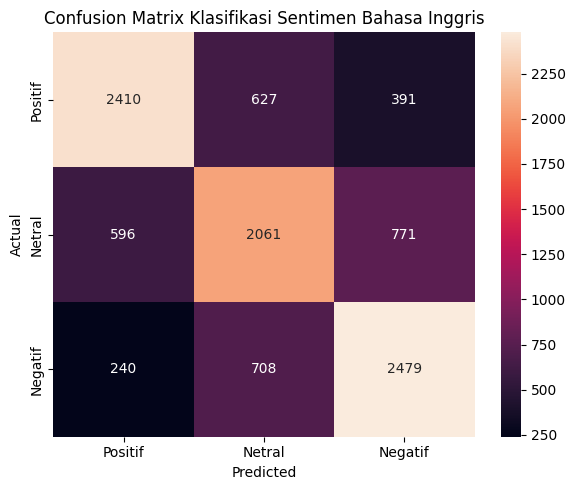

In [27]:
# ==========================================
# CONFUSION MATRIX BAHASA INGGRIS
# ==========================================

cm_en = confusion_matrix(
    y_test_en,
    y_pred_en,
    labels=[
        "positif",
        "netral",
        "negatif"
    ]
)

print("Confusion Matrix Bahasa Inggris:")
print(cm_en)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_en,
    annot=True,
    fmt="d",
    xticklabels=[
        "Positif",
        "Netral",
        "Negatif"
    ],
    yticklabels=[
        "Positif",
        "Netral",
        "Negatif"
    ]
)

plt.title(
    "Confusion Matrix Klasifikasi Sentimen Bahasa Inggris"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

Confusion Matrix Bahasa Indonesia:
[[184  14  68]
 [ 15 215  36]
 [ 32  13 220]]


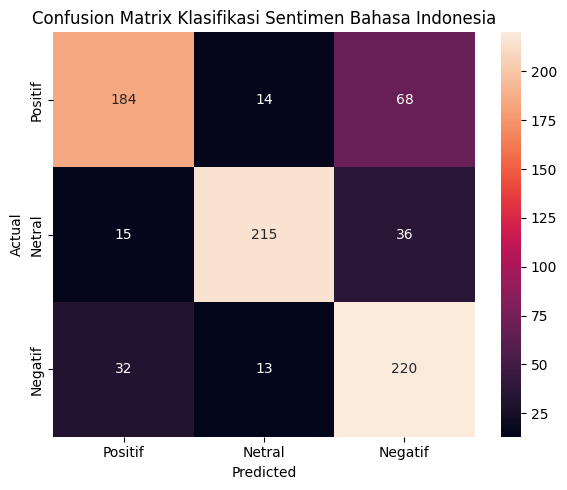

In [28]:
# ==========================================
# CONFUSION MATRIX BAHASA INDONESIA
# ==========================================

cm_id = confusion_matrix(
    y_test_id,
    y_pred_id,
    labels=[
        "positif",
        "netral",
        "negatif"
    ]
)

print("Confusion Matrix Bahasa Indonesia:")
print(cm_id)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_id,
    annot=True,
    fmt="d",
    xticklabels=[
        "Positif",
        "Netral",
        "Negatif"
    ],
    yticklabels=[
        "Positif",
        "Netral",
        "Negatif"
    ]
)

plt.title(
    "Confusion Matrix Klasifikasi Sentimen Bahasa Indonesia"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## Deteksi Anomali

Deteksi anomali dilakukan secara terpisah pada `df_model_en` dan `df_model_id`. Setiap `text_final` diprediksi menggunakan model dan vectorizer sesuai bahasanya, kemudian hasil prediksi disimpan pada kolom `sentiment_model`.

Status anomali ditentukan dengan membandingkan `polarity` berdasarkan rating dan `sentiment_model`:
- jika keduanya sama → `normal`;
- jika keduanya berbeda → `anomali`.

Dataset Bahasa Inggris dan Bahasa Indonesia tidak digabungkan pada tahap deteksi anomali.


In [29]:
# ==========================================
# DETEKSI ANOMALI BAHASA INGGRIS
# ==========================================

df_model_en["sentiment_model"] = model_nb_en.predict(
    tfidf_en.transform(
        df_model_en["text_final"]
    )
)

df_model_en["anomaly_status"] = (
    df_model_en["polarity"] != df_model_en["sentiment_model"]
).map({
    True: "anomali",
    False: "normal"
})

print("Hasil Deteksi Anomali Bahasa Inggris:")

print(
    df_model_en[
        [
            "review",
            "rating",
            "polarity",
            "sentiment_model",
            "anomaly_status"
        ]
    ].head(10)
)

print("\nDistribusi anomali Bahasa Inggris:")

print(
    df_model_en["anomaly_status"].value_counts()
)

Hasil Deteksi Anomali Bahasa Inggris:
                                              review  rating polarity  \
0  fr never expected steam's user care to be fast...       5  positif   
1  Steam needs to make game creators declare AI u...       1  negatif   
2                                        thank gaben       5  positif   
3  can't scan qr codes on GrapheneOS, that includ...       1  negatif   
4  app worked fine until a couple months ago now ...       2  negatif   
5  the authenticator app is asking me to use the ...       1  negatif   
6  You can't recover an account unless you log in...       1  negatif   
7  Not much to do, I thought I could buy games wh...       3   netral   
8  The steam app is wonderful and has worked perf...       5  positif   
9  best place for games and steam support is best...       5  positif   

  sentiment_model anomaly_status  
0         positif         normal  
1         negatif         normal  
2         positif         normal  
3         negatif 

In [30]:
# ==========================================
# DETEKSI ANOMALI BAHASA INDONESIA
# ==========================================

df_model_id["sentiment_model"] = model_nb_id.predict(
    tfidf_id.transform(
        df_model_id["text_final"]
    )
)

df_model_id["anomaly_status"] = (
    df_model_id["polarity"] != df_model_id["sentiment_model"]
).map({
    True: "anomali",
    False: "normal"
})

print("Hasil Deteksi Anomali Bahasa Indonesia:")

print(
    df_model_id[
        [
            "review",
            "rating",
            "polarity",
            "sentiment_model",
            "anomaly_status"
        ]
    ].head(10)
)

print("\nDistribusi anomali Bahasa Indonesia:")

print(
    df_model_id["anomaly_status"].value_counts()
)

Hasil Deteksi Anomali Bahasa Indonesia:
                                              review  rating polarity  \
0                                            So peak       5  positif   
1  iske andar Ham PC wale games Nahin khel sakte ...       1  negatif   
2                                        bahut bekar       5  positif   
3          login sangat tidak praktis Dan merepotkan       1  negatif   
4                                       bad just bad       1  negatif   
5                   anjg susah banget loginnya memeq       1  negatif   
6  bagus, tapi tolong tambahin opsi pembayaran vi...       5  positif   
7  gblk password sama email uda sama malah tetep ...       1  negatif   
8  CS STEAM THE BEST , akun kena hack bisa cepet ...       5  positif   
9                                           peak asf       5  positif   

  sentiment_model anomaly_status  
0         positif         normal  
1         negatif         normal  
2         positif         normal  
3         positi

## Penyimpanan Hasil

Hasil akhir disimpan secara terpisah agar konsisten dengan pipeline pemodelan. Dataset Bahasa Inggris disimpan sebagai `steam_reviews_model_result_en.csv`, sedangkan dataset Bahasa Indonesia disimpan sebagai `steam_reviews_model_result_id.csv`. Tidak dibuat file hasil model gabungan.


In [31]:
# ==========================================
# SIMPAN HASIL BAHASA INGGRIS
# ==========================================

df_model_en.to_csv(
    "steam_reviews_model_result_en.csv",
    index=False,
    encoding="utf-8"
)

df_result_en_check = pd.read_csv(
    "steam_reviews_model_result_en.csv"
)

print(
    f"File hasil model Bahasa Inggris tersimpan: "
    f"{len(df_result_en_check):,} baris"
)

print(
    df_result_en_check[
        [
            "review",
            "rating",
            "polarity",
            "sentiment_model",
            "anomaly_status"
        ]
    ].head()
)

File hasil model Bahasa Inggris tersimpan: 84,028 baris
                                              review  rating polarity  \
0  fr never expected steam's user care to be fast...       5  positif   
1  Steam needs to make game creators declare AI u...       1  negatif   
2                                        thank gaben       5  positif   
3  can't scan qr codes on GrapheneOS, that includ...       1  negatif   
4  app worked fine until a couple months ago now ...       2  negatif   

  sentiment_model anomaly_status  
0         positif         normal  
1         negatif         normal  
2         positif         normal  
3         negatif         normal  
4         negatif         normal  


In [32]:
# ==========================================
# SIMPAN HASIL BAHASA INDONESIA
# ==========================================

df_model_id.to_csv(
    "steam_reviews_model_result_id.csv",
    index=False,
    encoding="utf-8"
)

df_result_id_check = pd.read_csv(
    "steam_reviews_model_result_id.csv"
)

print(
    f"File hasil model Bahasa Indonesia tersimpan: "
    f"{len(df_result_id_check):,} baris"
)

print(
    df_result_id_check[
        [
            "review",
            "rating",
            "polarity",
            "sentiment_model",
            "anomaly_status"
        ]
    ].head()
)

File hasil model Bahasa Indonesia tersimpan: 6,068 baris
                                              review  rating polarity  \
0                                            So peak       5  positif   
1  iske andar Ham PC wale games Nahin khel sakte ...       1  negatif   
2                                        bahut bekar       5  positif   
3          login sangat tidak praktis Dan merepotkan       1  negatif   
4                                       bad just bad       1  negatif   

  sentiment_model anomaly_status  
0         positif         normal  
1         negatif         normal  
2         positif         normal  
3         positif        anomali  
4         negatif         normal  


## Catatan untuk Bab 3

Output pada penulisan harus mengikuti pipeline final pada notebook ini. Pengumpulan data menghasilkan atribut `negara`, `review_id`, `review`, `rating`, `date`, dan `bahasa`, kemudian kolom `polarity` ditambahkan melalui pelabelan berdasarkan rating.

Bahasa Inggris dan Bahasa Indonesia dipisahkan sebelum preprocessing dan tetap diproses secara terpisah sampai tahap penyimpanan hasil. Pada masing-masing bahasa dilakukan preprocessing, filtering, balancing, pembagian data 80:20, pembobotan TF-IDF, pemodelan Multinomial Naive Bayes, evaluasi, dan deteksi anomali. TF-IDF di-fit hanya menggunakan data latih masing-masing bahasa.

File hasil akhir yang digunakan adalah:
- `steam_reviews_model_result_en.csv` untuk Bahasa Inggris;
- `steam_reviews_model_result_id.csv` untuk Bahasa Indonesia.
